# Notebook to perform HieraType on CosMX RNA Data

# TODO
- ...

## Instructions

- 

## Imports

In [1]:
# Load Packages
library(Seurat)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(gtools)
library(tibble)
library(scPearsonPCA)
library(fs)
library(InSituCor)
library(pheatmap)
library(grid)
library(ComplexHeatmap)
library(viridis)
library(circlize)
library(HieraType)
library(mvtnorm)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: Rcpp

ComplexHeatmap version 2.26.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published rese

In [2]:
# Load helper functions
source("helper_functions.R")

## Data Loading

In [3]:
# Define directories
seu_file_path <- file.path("../outputs/TMA18/seurat_objects/merged_object_TMA18_IST_louvain_initial.RDS")
out_dir <- "../outputs" # Folder for outputs
study_name <- "TMA18"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
full_out_dir <- file.path(out_dir, study_name, "HieraType")
dir.create(full_out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

Define Parameters

In [4]:
ASSAY_NAME <- "RNA"
sdimx_col   <- "x_slide_mm"
sdimy_col   <- "y_slide_mm"
study_id_col <- "study_id"
region_col  <- "region"
annotation_col <- "scpearson_clusters_nobatch_res1.2" #final_annotation
cell_id_col <- "cell_ID_new"
# annotation_col <- "broad_annotation"

# HieraType / clustering parameters
graph_slot  <- "scpearson_graph_nobatch"            # Seurat Graph slot holding the NN adjacency matrix
cluster_col <- "scpearson_clusters_nobatch_res1.2"  # Louvain cluster column in metadata

# Tag used to namespace all output files — change when re-running with different params
run_tag <- paste0(study_name, "_unfiltered_", cluster_col)

# Subset
subset <- FALSE

Loading Seurat object

In [5]:
# Load Seurat object
seu <- readRDS(seu_file_path)

In [6]:
# colnames(seu@meta.data)
head(seu@meta.data, n=5)

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.G,⋯,GABAergic.synapse,Gap.Junctions,Glutamatergic.synapse,Microglia.Neurodegenerative.Phenotype..MGnD.,Myelogenesis,Neuroactive.Ligands.and.Receptors,Neurogenesis,Oligodendrocyte.Differentiation,Transmitter.Response,Transmitter.Storage
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18_c_1_100_100,100,23200,0.79,1848,915,207,164,1099.8,3272,371.9,⋯,0.006132972,0.051336898,0.01585921,0.04934135,0.04145120,0.03343709,0.1521876,0.0344877345,0.04864658,0.03100233
18_c_1_100_107,100,2805,0.92,1713,926,57,62,1391.7,3480,366.9,⋯,0.021275441,0.000000000,0.03598344,0.05497601,0.00155955,0.03868360,0.1880175,0.0000962001,0.04341164,0.00000000
18_c_1_100_113,100,9714,0.87,2185,1009,133,153,1034.4,2408,332.1,⋯,0.033378562,0.009014515,0.02770186,0.00000000,0.03426906,0.03424039,0.1780356,0.0406926407,0.02076949,0.02975913
18_c_1_100_123,100,6857,0.73,584,1043,83,113,871.4,1332,340.7,⋯,0.024477612,0.006722689,0.02989648,0.00000000,0.01305097,0.02701074,0.1608036,0.0253968254,0.03051583,0.03830614
18_c_1_100_157,100,8809,0.99,2257,1291,109,110,782.8,4068,274.9,⋯,0.033487110,0.000000000,0.04028986,0.03913805,0.02721005,0.02020785,0.2076031,0.0348725349,0.03098400,0.03830614


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


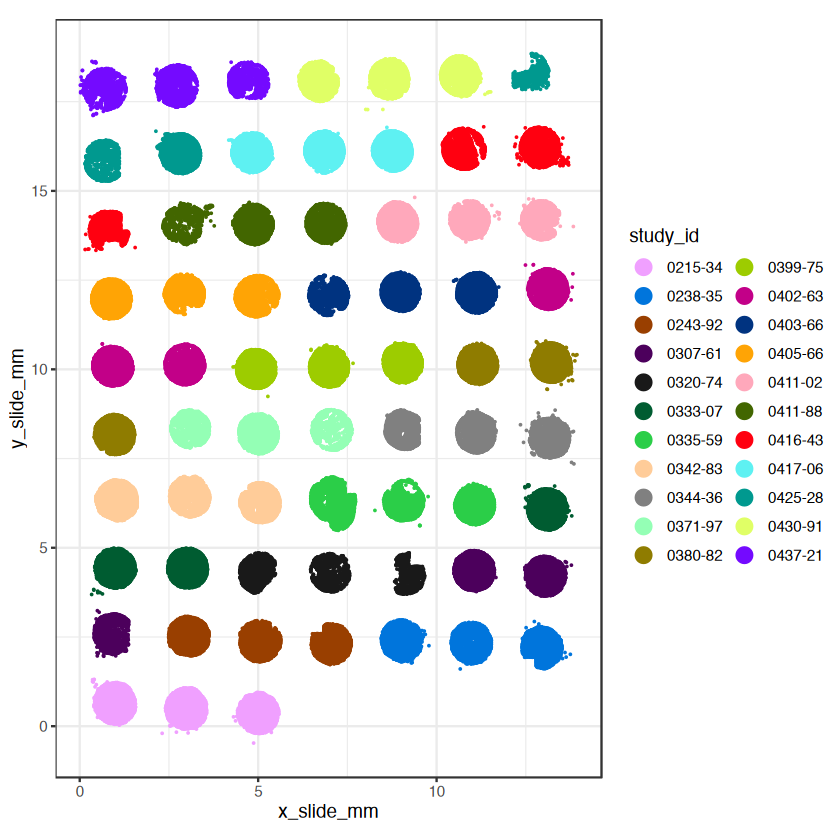

In [7]:
# Visualize the data
xyplot(study_id_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [8]:
unique(seu@meta.data[[study_id_col]])
unique(seu@meta.data[[region_col]])

[1] "0411-88" "0405-66" "0402-63" "0425-28" "0371-97" "0342-83" "0333-07"
 [8] "0243-92" "0215-34" "0437-21" "0416-43" "0417-06" "0399-75" "0320-74"
[15] "0430-91" "0403-66" "0335-59" "0411-02" "0344-36" "0238-35" "0380-82"
[22] "0307-61"

[1] 13 14 15 2  16 17 18 19 20 21 3  22 23 24 25 26 1  27 28 29 30 31 32 4  33
[26] 34 35 36 37 38 39 40 41 42 5  43 44 45 46 47 48 49 50 51 52 6  53 54 55 56
[51] 57 58 59 60 61 62 63 7  64 65 66 8  9  10 11 12
66 Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 66

Setting

In [10]:
if (subset) {

    # Filter for one patient only
    seu <- subset(seu, subset = study_id %in% c("0238-35"))

    # Filter for one region only
    # seu <- subset(seu, subset = region %in% c("18_C9"))

}

# Drop unused levels
seu@meta.data[[region_col]] <- droplevels(seu@meta.data[[region_col]])

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


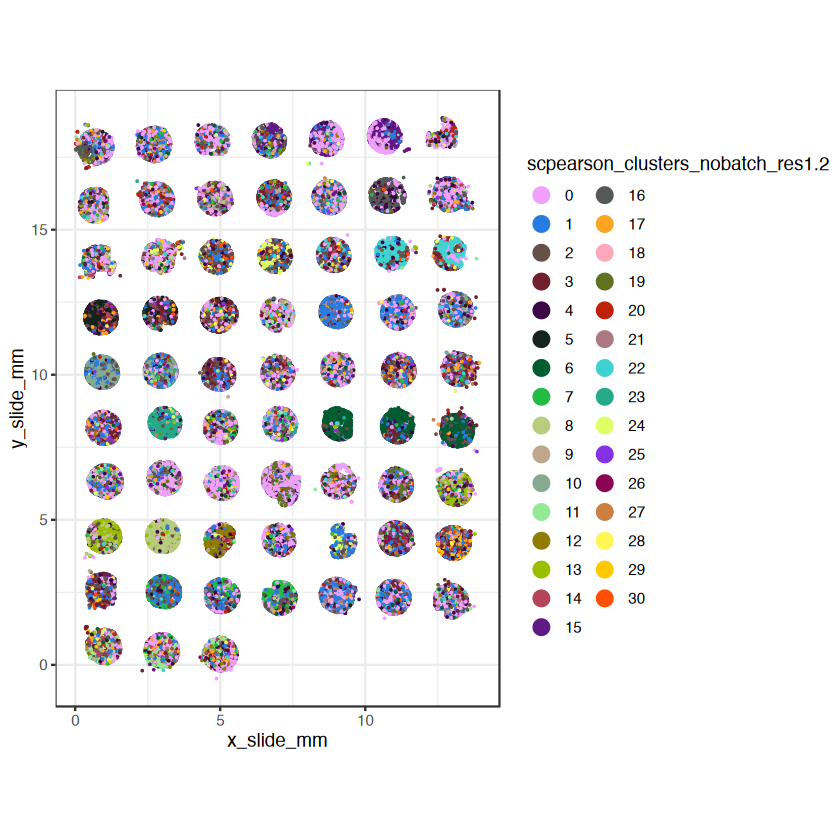

In [11]:
# Visualize the data
xyplot(annotation_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [12]:
nrow(seu)
ncol(seu)

[1] 6175

[1] 206450

Prepare the data

In [13]:
# Counts Data
counts <- Matrix::t(seu[[ASSAY_NAME]]$counts)
neg_counts <- Matrix::t(seu[["negprobes"]]$counts)
metadata <- seu@meta.data # row-aligned with the counts matrix
metadata$neg_total_counts <- Matrix::rowSums(neg_counts)
metadata$negmean <- Matrix::rowMeans(neg_counts)
xy <- as.matrix(metadata[, c(sdimx_col, sdimy_col)])

# Quick check: are the cell IDs of 'counts', 'metadata', and 'xy' in the same order?
all(rownames(counts) == rownames(metadata))
all(rownames(counts) == rownames(xy))

## normalize counts matrix using efficient sparse matrix calls:
scale_row <- mean(metadata$nCount_RNA) / metadata$nCount_RNA
norm <- counts
norm@x <- norm@x * scale_row[norm@i + 1L]

[1] TRUE

[1] TRUE

## Extract Adjacency Matrix

In [14]:
# The NN adjacency matrix was stored back into the Seurat object as a Seurat Graph.
# Graph objects inherit from dgCMatrix so they can be subsetted and used directly.
adjacency_matrix <- seu[[graph_slot]]

# Align rows/cols to the cells present in the counts matrix (handles any subset)
adjacency_matrix <- adjacency_matrix[rownames(counts), rownames(counts)]

cat("Adjacency matrix dimensions:", dim(adjacency_matrix), "\n")
cat("Non-zero entries:", Matrix::nnzero(adjacency_matrix), "\n")

Adjacency matrix dimensions: 206450 206450 
Non-zero entries: 10719460 


## Run HieraType — Levels 1 & 2 (Broad + Immune Subtyping)

In [15]:
# Build the two-level pipeline:
#   L1: classify every cell as immune vs. non-immune
#   L2: sub-classify immune cells (B, T, macrophage, DC, neutrophil, …)
pipeline_io_rna <- HieraType::make_pipeline(
    markerslists = list(
        "l1" = HieraType::markerslist_l1,
        "l2" = HieraType::markerslist_immune
    ),
    priors          = list("l2" = "l1"),
    priors_category = list("l2" = "immune")
)

# Cache path – flip to FALSE after first run to reload from disk instead
ht_l1l2_file <- file.path(full_out_dir, paste0("hieratype_l1l2_", run_tag, ".RDS"))

if (TRUE) {
    message("Running HieraType L1 + L2 ...")
    hieratyperes <- HieraType::run_pipeline(
        pipeline         = pipeline_io_rna,
        counts_matrix    = counts,
        totalcounts      = metadata$nCount_RNA,
        adjacency_matrix = adjacency_matrix[rownames(counts), rownames(counts)]
    )
    saveRDS(hieratyperes, ht_l1l2_file)
    message("Done. Saved to: ", ht_l1l2_file)
} else {
    message("Loading cached HieraType L1+L2 results from: ", ht_l1l2_file)
    hieratyperes <- readRDS(ht_l1l2_file)
}

Running HieraType L1 + L2 ...

Warning message in validate_markerslist(markerslist, available_genes):
“plasma:  the specified index markers: IGHG1 were not found.
4 remaining:IGHG1/2,IGHA1,MZB1,JCHAIN”
Removed 129 predictor genes not found in the counts matrix: OCLN, DSG1, DSG2, MUC16, CEACAM5, SPINT1, GJB2, GJB6, FXYD3, ST14, AGR3, CLCA2, SERPINB3, LGALS7, ANXA3, ANXA6, ANXA8, CDH17, DSC1, GJB3, GJB4, GJB5, TJP3, PARD6B, CRB3, PVRL1, PVRL2, PVRL3, FOXQ1, CLDN15, CLDN18, CLDN23, GPRC5A, S100A11, MUC5AC, VIL1, ALPI, CHGB, SPINK4, FABP2, SLC5A1, SLC6A20, CA4, DEFA5, REG3A, DUOX2, CLDN2, MUC13, TRIM31, TP63, ESRP1, ESRP2, RBP2, ALOX15, ABCC2, ABCG2, ECSCR, ESM1, GJA5, GJA4, GPR116, ADAMTS1, S1PR1, S1PR3, FOXC2, SMAD6, FLT4, VEZF1, CD248, NOSTRIN, LAMB2, ARHGEF15, SDC4, LOXL1, LOXL3, LOXL4, ELN, EMILIN1, EMILIN2, LTBP3, LTBP4, ITGA11, MMP8, MMP10, TIMP4, ADAMTS4, CTGF, PRRX1, PRRX2, IGHG1, PPIB, SSR4, SEC61B, GPRC5D, HSPA5, PDIK1L, BLIMP1, CD20, CD56, KLRC1, B3GAT1, KIR2DL1, KIR2DL2, KIR2D

## Run HieraType — Level 3 (T Cell Fine Typing)

In [16]:
# Identify T cells from the L1 probability table
# (L1 labels immune cells; T cells carry the "tcell" tag in celltype_granular)
tcell_ids <- hieratyperes$post_probs$l1[celltype_granular=="tcell"][["cell_ID"]]

cat("T cells identified at L1:", length(tcell_ids), "\n")

# Cache path
ht_l3_file <- file.path(full_out_dir, paste0("hieratype_l3_tcell_", run_tag, ".RDS"))

if (TRUE) {
    message("Running HieraType L3 (T cell fine typing) on ", length(tcell_ids), " cells ...")
    hieratyperes_tcell <- HieraType::run_pipeline(
        pipeline              = HieraType::pipeline_tcell,
        counts_matrix         = counts[tcell_ids, , drop = FALSE],
        totalcounts           = metadata[tcell_ids, "nCount_RNA"],
        adjacency_matrix      = adjacency_matrix[tcell_ids, tcell_ids],
        celltype_call_threshold = 0.5
    )
    saveRDS(hieratyperes_tcell, ht_l3_file)
    message("Done. Saved to: ", ht_l3_file)
} else {
    message("Loading cached HieraType L3 results from: ", ht_l3_file)
    hieratyperes_tcell <- readRDS(ht_l3_file)
}

T cells identified at L1: 16728 


Running HieraType L3 (T cell fine typing) on 16728 cells ...

Removed 1 predictor genes not found in the counts matrix: STAT5

totalcount norm (all): 2026-02-27 15:09:47.620026

lagging predictors (all): 2026-02-27 15:09:47.9168

Modeling cd8t. 2026-02-27 15:09:47.9746

lagging predictors: 2026-02-27 15:09:47.999352

lagging response: 2026-02-27 15:09:48.294942

cross-prod calcualtions: 2026-02-27 15:09:48.297984

fitting model to index marker: CD8B. 2026-02-27 15:09:48.714239

fitting model to index marker: CD8A. 2026-02-27 15:09:48.738756

Modeling cd4t. 2026-02-27 15:09:48.744411

lagging predictors: 2026-02-27 15:09:48.757827

lagging response: 2026-02-27 15:09:49.058969

cross-prod calcualtions: 2026-02-27 15:09:49.061673

fitting model to index marker: CD4. 2026-02-27 15:09:49.465509

fitting mixture component for cd8t

fitting mixture component for cd4t

Removed 10 predictor genes not found in the counts matrix: GIMAP5, THEMIS, ANKRD55, ZNF831, PIK3IP1, STAT5, ALOX15, CCR8, IL35

## Unify HieraType Results

In [17]:
# unify calls
htclust <- hieratyperes$post_probs$l1$celltype_granular
names(htclust) <- hieratyperes$post_probs$l1$cell_ID
htclust[hieratyperes_tcell$post_probs$tmajor$cell_ID] <- hieratyperes_tcell$post_probs$tmajor$celltype_granular
htclust <- htclust[match(rownames(metadata), names(htclust))]
metadata$hieratype_call <- htclust

cat("HieraType call distribution:\n")
print(sort(table(metadata$hieratype_call), decreasing = TRUE))

HieraType call distribution:

   epithelial    fibroblast   endothelial smooth_muscle    macrophage 
        74152         28859         19720         19419         11768 
     monocyte        plasma         bcell     dendritic    neutrophil 
        10889         10000          3802          3127          3050 
      cd8_tem            nk cd8_cytotoxic      cd4_treg          mast 
         2787          2672          2506          2479          2264 
    cd8_naive cd8_exhausted       cd4_tcm       cd4_th2     cd4_naive 
         1351          1245          1187          1042          1031 
      cd4_tem       cd4_th1      cd4_th17       cd8_tcm 
         1021           753           672           654 


## Merge HieraType with Louvain Clusters

In [18]:
# Collect all labels that should be preserved after integration:
supervised_labels_keep <- unique(na.omit(metadata$hieratype_call))
cat("Supervised labels to keep (", length(supervised_labels_keep), "):\n")
print(sort(supervised_labels_keep))

# Integrate Louvain clusters with HieraType supervised calls.
# - dissolve_smallcluster_if_overwritten_prop_greaterthan:
#     if >90 % (or >50 %) of a cluster is overwritten by a supervised label,
#     dissolve the cluster and keep the supervised label.
# - and_dissolve_smallcluster_if_finalcluster_prop_lessthan:
#     additionally dissolve clusters that are <5 % (or <1 %) of the dataset.
ht_integrated_file <- file.path(full_out_dir, paste0("hieratype_integrated_", run_tag, ".RDS"))

if (TRUE) {
    message("Running celltype_label_integration ...")
    integrated_labels <- HieraType::celltype_label_integration(
        metadata             = metadata,
        adjacency_mat        = adjacency_matrix,
        cellid_colname       = cell_id_col,
        unsupervised_colname = cluster_col,
        supervised_colname   = "hieratype_call",
        supervised_labels_keep = supervised_labels_keep,
        dissolve_smallcluster_if_overwritten_prop_greaterthan   = c(0.9, 0.5),
        and_dissolve_smallcluster_if_finalcluster_prop_lessthan = c(0.05, 0.01)
    )
    saveRDS(integrated_labels, ht_integrated_file)
    message("Done. Saved to: ", ht_integrated_file)
} else {
    message("Loading cached integrated labels from: ", ht_integrated_file)
    integrated_labels <- readRDS(ht_integrated_file)
}

celltype <- metadata$celltype <- integrated_labels$celltype[match(metadata[[cell_id_col]], integrated_labels[[cell_id_col]])]

cat("\nFinal celltype distribution:\n")
print(sort(table(metadata$celltype), decreasing = TRUE))

Supervised labels to keep ( 24 ):
 [1] "bcell"         "cd4_naive"     "cd4_tcm"       "cd4_tem"      
 [5] "cd4_th1"       "cd4_th17"      "cd4_th2"       "cd4_treg"     
 [9] "cd8_cytotoxic" "cd8_exhausted" "cd8_naive"     "cd8_tcm"      
[13] "cd8_tem"       "dendritic"     "endothelial"   "epithelial"   
[17] "fibroblast"    "macrophage"    "mast"          "monocyte"     
[21] "neutrophil"    "nk"            "plasma"        "smooth_muscle"


Running celltype_label_integration ...

Done. Saved to: ../outputs/TMA18/HieraType/hieratype_integrated_TMA18_unfiltered_scpearson_clusters_nobatch_res1.2.RDS




Final celltype distribution:

   epithelial    fibroblast   endothelial smooth_muscle    macrophage 
        74152         28859         19720         19419         11768 
     monocyte        plasma         bcell     dendritic    neutrophil 
        10889         10000          3802          3127          3050 
      cd8_tem            nk cd8_cytotoxic      cd4_treg          mast 
         2787          2672          2506          2479          2264 
    cd8_naive cd8_exhausted       cd4_tcm       cd4_th2     cd4_naive 
         1351          1245          1187          1042          1031 
      cd4_tem       cd4_th1      cd4_th17       cd8_tcm 
         1021           753           672           654 


## Save Outputs

In [19]:
# Save updated metadata as RDS (dynamic name based on run_tag)
meta_out_file <- file.path(full_out_dir, paste0("metadata_with_celltypes_", run_tag, ".RDS"))
saveRDS(metadata, meta_out_file)
message("Metadata saved to: ", meta_out_file)

# Add new columns back to the Seurat object and save
# (Seurat file name is fixed — not parameterised by run_tag)
seu$hieratype_call <- metadata[colnames(seu), "hieratype_call"]
seu$celltype       <- metadata[colnames(seu), "celltype"]

seu_out_file <- file.path(out_dir_seu, sub("\\.RDS$", "_hieratype.RDS", basename(seu_file_path)))
saveRDS(seu, seu_out_file)
message("Seurat object saved to: ", seu_out_file)

Metadata saved to: ../outputs/TMA18/HieraType/metadata_with_celltypes_TMA18_unfiltered_scpearson_clusters_nobatch_res1.2.RDS

Seurat object saved to: ../outputs/TMA18/seurat_objects/merged_object_TMA18_IST_louvain_initial_hieratype.RDS



## Marker Heatmaps

### Heatmap 1 — Canonical Index Markers

In [20]:
# Pull index-marker gene vectors from both pipelines
indexmarkers <- unique(c(
  unlist(pipeline_io_rna$markerslists$l2)[grepl("index_marker", names(unlist(pipeline_io_rna$markerslists$l2)))],
  unlist(HieraType::pipeline_tcell)[grepl("index_marker", names(unlist(HieraType::pipeline_tcell)))]
))
cat("Index markers found:", length(indexmarkers), "\n")

# Restrict to genes present in the norm matrix
indexmarkers <- indexmarkers[indexmarkers %in% colnames(norm)]
cat("Index markers in norm matrix:", length(indexmarkers), "\n")

# Compute per-celltype fold-change metrics on the index-marker subset
fc_idx <- HieraType::clusterwise_foldchange_metrics(
  normed         = Matrix::t(norm[, indexmarkers]),
  metadata       = data.frame("cell_ID" = names(htclust), "hieratype_call" = htclust),
  cluster_column = "hieratype_call"
)

# Save heatmap
hm1_file <- file.path(full_out_dir, paste0("heatmap_index_markers_", run_tag, ".pdf"))
pdf(hm1_file, width = 14, height = 10)
HieraType::marker_heatmap(fc_idx)
dev.off()
message("Index-marker heatmap saved to: ", hm1_file)

Index markers found: 72 
Index markers in norm matrix: 69 
  |======================================================================| 100%

agg_record_921726391 
                   2

Index-marker heatmap saved to: ../outputs/TMA18/HieraType/heatmap_index_markers_TMA18_unfiltered_scpearson_clusters_nobatch_res1.2.pdf



### Heatmap 2 — Data-Driven Markers (All Genes)

In [21]:
# Use the full norm matrix (all genes) to let HieraType pick the most discriminative markers per cell type.
fc_all <- HieraType::clusterwise_foldchange_metrics(
    normed         = Matrix::t(norm),
    metadata       = data.frame("cell_ID" = names(htclust), "hieratype_call" = htclust),
    cluster_column = "hieratype_call"
)

# Save heatmap
hm2_file <- file.path(full_out_dir, paste0("heatmap_datadriven_markers_", run_tag, ".pdf"))
pdf(hm2_file, width = 14, height = 10)
HieraType::marker_heatmap(fc_all)
dev.off()
message("Data-driven marker heatmap saved to: ", hm2_file)

  |======================================================================| 100%

agg_record_502447910 
                   2

Data-driven marker heatmap saved to: ../outputs/TMA18/HieraType/heatmap_datadriven_markers_TMA18_unfiltered_scpearson_clusters_nobatch_res1.2.pdf



### Cluster QC Plots

In [23]:
cluster_col = "hieratype_call"
cluster_cls <- InSituType::colorCellTypes(freqs = table(seu@meta.data[[cluster_col]]), palette = "brewers")
reduction = "scpearson_umap_nobatch"

In [24]:
    CT_QC_plot(seu = seu, cluster_col = cluster_col, cluster_pal = cluster_cls, annotation_col = NULL, annotation_pal = NULL, out_dir = full_out_dir, reduction = reduction)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



[[1]]


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”



[[2]]


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”



[[3]]


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”



[[4]]


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


agg_record_511183325 
                   2

## Session Info

In [22]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-apple-darwin13.4.0
Running under: macOS Tahoe 26.2

Matrix products: default
BLAS/LAPACK: /Users/fs2829/miniforge3/envs/COSMX_RNA_env_proj_ADANA/lib/libopenblasp-r0.3.30.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] mvtnorm_1.3-3         HieraType_1.0.3       circlize_0.4.17      
 [4] viridis_0.6.5         viridisLite_0.4.2     ComplexHeatmap_2.26.0
 [7] pheatmap_1.0.13       InSituCor_0.0.0.9000  fs_1.6.6             
[10] scPearsonPCA_0.0.1.0  tibble_3.3.1          gtools_3.9.5         
[13] cluster_2.1.8.1       ggrastr_1.0.2         RColorBrewer_1.1-3   
[16] pals_1.10             ggrepel_0.9.6         harmony_1.2.4        
[19] Rcpp_1.1.1            Matrix_1.7-4          data.table_1.17.8    
[22] patchwork_1.3.2       g